In [ ]:
!pip install -Uq langgraph openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.3 MB/s eta 0:00:00


In [ ]:
!python --version

Python 3.12.12


# Pattern I: ReAct - Reasoning & Acting


In [ ]:
import operator
from typing import TypedDict, Annotated, Literal

from openai import OpenAI
from langgraph.graph import StateGraph, START, END


# ------------------------------------------------------------
# 1) State：用 TypedDict + reducer（避免在 node 內直接 mutate）
# ------------------------------------------------------------
class ReActState(TypedDict):
    input: str
    history: Annotated[list[str], operator.add]  # append-only，每一次生成的結果會附加在最後
    result: str  # 每一次生成的結果
    next_step: Literal["generate", "end"]
    iter: int
    max_iters: int


# ------------------------------------------------------------
# 2) LLM：使用新版 OpenAI SDK（Responses API）
#    - 預設會讀環境變數 OPENAI_API_KEY
# ------------------------------------------------------------
from google.colab import userdata

client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

def llm_text(prompt: str) -> str:
    resp = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
    )
    return (resp.output_text or "").strip()


# ------------------------------------------------------------
# 3) Nodes：回傳「狀態更新」而不是 state.xxx = ...
# ------------------------------------------------------------
def think_node(state: ReActState) -> ReActState:
    # 邏輯停止條件：避免永遠 generate
    if state["iter"] >= state["max_iters"]:
        return {"next_step": "end"}

    prompt = (
        "你是流程控制器。請根據輸入與歷史，判斷下一步要不要繼續生成。\n"
        f"輸入：{state['input']}\n"
        f"歷史：{state['history']}\n\n"
        "規則：只能回覆一個單字：generate 或 end。\n"
        "回覆："
    )

    decision = llm_text(prompt).lower()
    print(f"第{state["iter"]+1}次思考的決定：\n---------------------\n{decision}\n\n")

    # Get decision for the next step: continue to REVISE or END the process
    next_step: Literal["generate", "end"] = "generate" if "generate" in decision else "end"

    # iter + 1（用回傳的 update 方式更新）
    return {"next_step": next_step, "iter": state["iter"] + 1}


def generate_node(state: ReActState) -> ReActState:
    prompt = (
        "請將以下內容改寫成正式、專業的公司用語（偏會議記錄/公文語氣）。\n"
        f"原始輸入：\n--------\n{state['input']}\n\n"
        f"已生成歷史：\n----------\n{state['history']}\n\n"
        "請直接輸出改寫結果："
    )

    result = llm_text(prompt)
    print(f"第{state["iter"]}次生成結果：\n-----------\n{result}\n\n")

    # history 用 reducer 追加（回傳 list，operator.add 會把它接到原本 history 後面）
    return {
        "result": result,
        "history": [f"生成：{result}"],
    }


# ------------------------------------------------------------
# 4) Graph：START -> think -> (generate|END), generate -> think 形成 loop
# ------------------------------------------------------------
builder = StateGraph(ReActState)

builder.add_node("think", think_node)
builder.add_node("generate", generate_node)

builder.set_entry_point("think")

# Routing
# add_conditional_edges 的第二個參數是一個 condition function (a Callable)，這個 Callable 的傳入參數規定是 state
# LangGraph 會在節點執行後，自動把當前 state 傳給這個 function，然後 function 回傳的 value 會被拿來對應 path_map，決定下一個節點。
builder.add_conditional_edges(
    "think",
    lambda state: state["next_step"],
    {
        "generate": "generate",
        "end": END,
    }
)

builder.add_edge("generate", "think")

graph = builder.compile()


# ------------------------------------------------------------
# 5) Run：recursion_limit 是框架層安全網（防止意外循環）
# ------------------------------------------------------------
initial_state: ReActState = {
    "input": "會議中提及新產品預計於三月底左右發表，實際日期尚待確認。部分功能仍需補測，包裝與對外說明由行銷部後續整理。另提醒發佈前避免對外透露相關細節，相關注意事項將再補充。",
    "history": [],
    "result": "",
    "next_step": "generate",
    "iter": 0,
    "max_iters": 3,
}

final_state = graph.invoke(initial_state, config={"recursion_limit": 10})
print(">>>> 最終用語：\n", final_state["result"])
print(">>>> 總迭代次數：\n", final_state["iter"])
print(">>>> history：\n", final_state["history"])


第1次思考的決定：
---------------------
generate


第1次生成結果：
-----------
會議中提及新產品預計於三月底前後發表，具體日期仍待最終確認。部分功能尚需進行補充測試，包裝設計及對外說明資料由行銷部門負責後續整理。另提醒各單位於產品發佈前，務必避免對外洩露相關細節，相關注意事項將於後續補充通知。


第2次思考的決定：
---------------------
end


>>>> 最終用語：
 會議中提及新產品預計於三月底前後發表，具體日期仍待最終確認。部分功能尚需進行補充測試，包裝設計及對外說明資料由行銷部門負責後續整理。另提醒各單位於產品發佈前，務必避免對外洩露相關細節，相關注意事項將於後續補充通知。
>>>> 總迭代次數：
 2
>>>> history：
 ['生成：會議中提及新產品預計於三月底前後發表，具體日期仍待最終確認。部分功能尚需進行補充測試，包裝設計及對外說明資料由行銷部門負責後續整理。另提醒各單位於產品發佈前，務必避免對外洩露相關細節，相關注意事項將於後續補充通知。']


## 流程圖

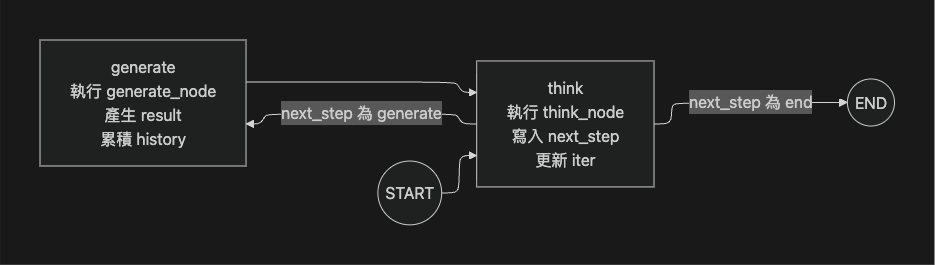

## 關於 reducer

```
class ReActState(TypedDict):
    input: str
    history: Annotated[list[str], operator.add]  # append-only
    result: str
    next_step: Literal["generate", "end"]
    iter: int
    max_iters: int
```

`history: Annotated[list[str], operator.add]` **這一行不是「型別註解而已」，而是在告訴「狀態機」：`history` 這個欄位在每次狀態更新時，要用 `operator.add` 來合併。**

也就是一句話版的理解：

👉 **`history` 是「只能累加、不能覆蓋」的欄位（append-only）**。

拆開來看這行到底在幹嘛。

---

`Annotated[list[str], operator.add]` 可以拆成三層來理解：

第一層，`list[str]`
這個很直覺，代表 `history` 是一個字串列表，例如：

```python
["user: 問題", "agent: 回答", "agent: 思考"]
```

第二層，`Annotated[...]`
`Annotated` 的意思是：

> **在不改變型別本身的情況下，附加「額外語意給框架用」**

注意一件很關鍵的事：
👉 **Python 自己不會理 `Annotated` 裡面的東西**
👉 **是 LangGraph / 狀態機 runtime 在讀它**

第三層，`operator.add`（這才是重點）

`operator.add` 等價於：

```python
lambda a, b: a + b
```

用在 `list` 上時，就是：

```python
["a", "b"] + ["c"] == ["a", "b", "c"]
```

---

把這三層合起來，語意就很清楚了：

### 這是在告訴 LangGraph：

> 當 graph 的某個 node 回傳一個新的 `history` 值時，
> **不要直接覆蓋舊的 history**，
> 而是用 `operator.add(old, new)` 把它們合併。

---

用一個「實際執行畫面」幫你對齊腦內模型。

假設目前 state 是：

```python
history = ["user: hi"]
```

某個 node 回傳：

```python
{"history": ["agent: hello"]}
```

因為你標了：

```python
Annotated[list[str], operator.add]
```

所以新的 state 會變成：

```python
history = ["user: hi", "agent: hello"]
```

而不是被覆蓋成：

```python
history = ["agent: hello"]
```

這就是註解裡寫的 `# append-only` 的真正意思。

---

為什麼在 ReAct / Agent state 裡這個設計很重要？

因為在 agent loop 裡：

* 每一步都在「追加」思考、觀察、行動
* **你絕對不希望不小心把前面的 reasoning 抹掉**
* history 本質上就是一條「不可回頭的 log」

這跟你之前在意的：

* 可審計
* 可追溯
* deterministic state

是完全同一條設計哲學。

---

如果我用一句工程師等級的白話來幫你總結：

> `Annotated[list[str], operator.add]`
> = **這個欄位是狀態 log，不是暫存變數；更新時只能累加，不能覆蓋**

實用提醒（這個很容易踩雷）：

* **如果某個 node 回傳的 `history` 不是 list，而是單一字串**
  → runtime 會直接炸
* 正確姿勢永遠是：

```python
{"history": ["新的一步紀錄"]}
```

一句話 takeaway：
**這行不是型別裝飾，而是「狀態合併策略的宣告」；你其實已經在用一個非常乾淨的 append-only event log 模型了。**

如果你願意，下一步我可以幫你把這個 `ReActState` 對應成一張「State 合併語意表」，把每個欄位的更新策略一次講清楚。


# Pattern II: Reflection (使用 Command, langchain_openai)

In [ ]:
!pip install -Uq langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
from typing import TypedDict, Literal

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

# 建議用 langchain_openai（LangChain 生態內最常見）
from langchain_openai import ChatOpenAI


# ============================================================
# 1) State 定義（最新 Graph API 常見寫法：TypedDict）
# ============================================================
class ReflectionState(TypedDict):
    draft: str
    email: str
    feedback: str
    has_issue: bool
    iter: int
    max_iters: int


# ============================================================
# 2) LLM：用 ChatOpenAI（你也可以換成其他 provider）
# ============================================================
from google.colab import userdata
API_KEY=userdata.get('OPENAI_API_KEY')

llm = ChatOpenAI(
    api_key=API_KEY,
    model="gpt-4o-mini",
    temperature=0.2,
)


def llm_text(prompt: str) -> str:
    """把 LLM 回覆統一抽成字串。"""
    return llm.invoke(prompt).content.strip()


# ============================================================
# 3) Node: generate
#    注意：節點回傳「狀態更新」，不要直接 mutate state
# ============================================================
def generate_node(state: ReflectionState) -> dict:
    """
    先把草稿變成「像樣的第一版」
    """
    prompt = (
        "你是專業商務溝通助理。"
        "請將下列電子郵件草稿改寫成專業、禮貌、清楚的語氣，"
        "保留原意，但讓收件者容易理解並願意回覆。\n\n"
        f"草稿：\n{state['draft']}\n"
    )

    email = llm_text(prompt) # llm_text 函式已經把回覆字串抽出來了

    # 節點函式不要去 mutate state，而是「讀 state，回傳一個 dict 更新」
    # generate node 只執行一次，直接 assiagn iter 為 1 當做初始值即可。
    return {"email": email, "iter": 1}

# ============================================================
# 4) Node: reflect
#    原本的做法是：
#      reflect 節點先做出判斷 → 再透過 conditional edge 決定要走到 update 或 END，而 update 之後再回到 reflect。
#    新的寫法是：
#      reflect 直接回傳 `Command(update=..., goto=...)`。
#    這一次回傳同時完成了兩件事：
#      1. 寫入 feedback／has_issue，
#      2. 決定下一步要跳到哪個節點。
#    這正是 Command API 的設計目的：
#      把「控制流程」與「狀態更新」綁在同一個回傳裡，讓整張圖更容易閱讀，也比較不會把流程邏輯分散在外層。
#    補充說明："__end__" 是 LangGraph 內部用來對應 `END` 的實際字串值。
# ============================================================
def reflect_decide_node(state: ReflectionState) -> Command[Literal["update", "__end__"]]:
    """
    reflection + decision
    反思節點 / 審稿 / 檢查哨
    - 產生 feedback
    - 設定 has_issue
    - 同時決定 goto：要去 update 還是 END
      - 如果 OK：直接放行到終點 END
      - 如果不 OK：發一張「修改清單」，把你打回 update
    - 用 Command 來做控制流（而不是在外面額外寫一堆 conditional edges），這是官方 Graph API 目前最標準、也最可讀的做法之一
    - LangGraph Note: "__end__" corresponds to LangGraph.END.
                      END is a symbolic constant whose internal node key is "__end__".
                      Using END in implementation and "__end__" in Literal[...] refers to the same target.
    """
    prompt = (
        "你是嚴格的郵件審稿人。"
        "請檢查下列郵件是否存在語氣、結構、清晰度、禮貌或資訊不足的問題。"
        "若有問題：請用條列列出具體修改建議（越具體越好）。"
        "若沒有問題：請只輸出「無問題」。\n\n"
        f"郵件：\n{state['email']}\n"
    )
    feedback = llm_text(prompt)
    print(f">>> 第 {state['iter']} 次審稿\n")
    print(f">>> 反饋：{feedback}")

    has_issue = feedback != "無問題"

    # 迭代停止條件：沒問題 or 超過最大迭代
    reached_limit = state["iter"] >= state["max_iters"]
    print(f"reached_limit: {reached_limit}")

    should_end = (not has_issue) or reached_limit

    # LangGraph note:
    # END is a symbolic constant whose internal node key is "__end__".
    # Using END in implementation and "__end__" in Literal[...] refers to the same target.
    goto = END if should_end else "update"

    print(f"END 是什麼：{type(END)}")
    print(f"goto 變數的型別：{type(goto)}")

    return Command(
        update={"feedback": feedback, "has_issue": has_issue},
        goto=goto,
    )

# ============================================================
# 5) Node: update
#    根據審稿後的 feedback 修正郵件
# ============================================================
def update_node(state: ReflectionState) -> dict:
    prompt = (
        "你是專業郵件編輯。請依照『建議』修正文案，"
        "確保語氣專業、資訊完整、行文清楚。\n\n"
        f"建議：\n{state['feedback']}\n\n"
        f"原始郵件：\n{state['email']}\n"
    )
    revised = llm_text(prompt)

    return {
        "email": revised,
        "iter": state["iter"] + 1,  # 有動到文案內容，就增加一次修改次數
    }


# ============================================================
# 6) Build Graph：START -> generate -> reflect -> (update -> reflect)* -> END
# ============================================================
builder = StateGraph(ReflectionState)

builder.add_node("generate", generate_node)
builder.add_node("reflect_decide", reflect_decide_node)
builder.add_node("update", update_node)

# reflect 節點已經利用 Commnad 來控制跳至哪一個節點
# 故不再使用 conditional edge

builder.add_edge(START, "generate")
builder.add_edge("generate", "reflect_decide")
builder.add_edge("update", "reflect_decide")

graph = builder.compile()


# ============================================================
# 7) Demo run
# ============================================================
if __name__ == "__main__":
    initial_state: ReflectionState = {
        "draft": "嗨，明天可以開會嗎？",
        "email": "",
        "feedback": "",
        "has_issue": True,
        "iter": 0,
        "max_iters": 3,
    }

    result = graph.invoke(initial_state)

    print("=== 最終郵件 ===")
    print(result["email"])
    print("\n=== 最後一次 feedback ===")
    print(result["feedback"])
    print("\n=== 迭代次數 ===")
    print(result["iter"])


>>> 第 1 次審稿

>>> 反饋：- 主旨可以更具體，例如「明天會議安排請求」或「請求安排明天會議」。
- 在開頭的問候語後，可以加上一句簡短的背景說明，例如「我想與您討論關於[具體主題]的事項」。
- 在會議的具體時間上，可以提供幾個選擇，例如「我可以在上午10點或下午2點進行會議，您覺得哪個時間更合適？」這樣可以提高回覆的效率。
- 結尾的「祝好」可以改為「祝您一切順利」或「期待您的回覆」，使語氣更為友好。
reached_limit: False
END 是什麼：<class 'str'>
goto 變數的型別：<class 'str'>
>>> 第 2 次審稿

>>> 反饋：1. 主旨可以更具體：建議在主旨中提及具體主題，例如「請求安排明天會議以討論[具體主題]」。

2. 開頭的問候語可以更正式：建議使用「尊敬的 [收件者姓名]」來提升正式程度。

3. 會議主題應更明確：在郵件中提及的「[具體主題]」應具體化，讓收件者清楚會議的內容。

4. 提供更多的時間選擇：除了上午10點和下午2點，建議提供更多的時間選擇，以便收件者有更多的靈活性。

5. 結尾可以更具體：在結尾中可以加入「期待您的回覆」的具體時間，例如「希望能在今天內收到您的回覆」。

6. 聯絡方式應包含完整信息：建議在聯絡方式中提供電話號碼或其他聯絡方式，以便收件者能更方便地聯繫您。

7. 簽名格式：建議在簽名中使用「敬上」或「祝好」等更正式的結尾語，以提升專業形象。
reached_limit: False
END 是什麼：<class 'str'>
goto 變數的型別：<class 'str'>
>>> 第 3 次審稿

>>> 反饋：1. **主旨具體化**：建議在主旨中明確指出具體主題，以便收件者一目了然。例如：「請求安排明天會議以討論[具體主題]（如：市場調查結果）」

2. **開頭問候**：可以考慮增加一個更具體的問候語，例如「希望您一切安好，工作順利。」這樣可以讓語氣更親切。

3. **會議時間選擇**：建議在提供時間選擇時，增加一個「如果這些時間不方便，請告訴我您合適的時間。」這樣可以顯示出對收件者時間的尊重。

4. **回覆時間要求**：在「希望能在今天內收到您的回覆」這句話中，建議使用更禮貌的語氣，例如「如果方便的話，希望能在今天內收到您的回覆，謝謝！」

## Graph-level 顯式（conditional_edge）與 Node-level 顯式（Command goto）

```
雖然你說是“顯式”的控制流
但是從建graph的角度來看，其實比較難以用更外圍的角度來看流程
因為這個方式把流程控制寫在 node 裡面，雖然這也彰顯了 single responsibility 的模式
不過在建圖時刻意不寫 conditional_edge 其實對有些人來說還是要習慣的
甚至當節點一多時，還必須去每個節點內部觀察決定是怎麼被實現的
```

你這個觀察很到位，而且不是「不習慣」而已，是在講一個真實的工程 trade-off：
把控制流放在 node 裡（Command goto）會讓「局部決策很清楚」，但「全局拓撲變模糊」。當圖一大，確實會變成你說的那種狀況：要到每個 decision node 裡看它怎麼跳。

我用更外圍、可操作的角度把這件事講透，然後給你幾個你可以立刻採用的做法（不需要改變你現有架構太多）。

---

你現在其實在比較兩種「顯式」：

A）Graph-level 顯式（conditional_edge）
你在建圖時就把所有分支寫出來，所以整張圖的拓撲在 builder 那一層就完整可見。
代價是：決策邏輯與 state 更新往往被拆成兩處（node 產生某個 flag，外面讀 flag 決定走向），對治理來說會有「判斷依據在哪裡」的分散感。

B）Node-level 顯式（Command goto）
決策與更新在同一個地方（同一個 return），局部讀起來很像「一個原子轉移」。
代價就是你說的：全局視角要靠讀 node 才拼得起來。

所以你講的「要習慣」不是情緒問題，而是**你在意的是全局可讀性**，而 Command 的默認寫法會弱化這件事。

---

我建議你不要把它看成「二選一」，而是把 LangGraph 當作三層可讀性要同時滿足：

1）全局拓撲（builder 那層一眼看得懂）
2）局部決策（node 內部一眼看得懂）
3）可追溯與治理（trace / audit 一眼看得懂）

Command 強化 2、3；conditional_edge 強化 1。你要的是三者兼顧。

下面是幾個很實戰的折衷做法。

---

做法一：只把「真正重要的分支」留在 graph-level，其餘留在 node-level

最常見的痛點不是「有 goto」，而是「每個小決策都 goto」。
你可以規定：

* 只有「會改變流程結構」的決策（例如：進入人工審核、升級、走另一條子流程）才用 conditional_edge
* 像 Reflection 這種純 loop、純 retry 的控制，用 Command 放 node 裡沒問題

這樣你的 builder 仍然能呈現“架構級分支”，而不是被各種小旗標塞滿。

腦內畫面是：

* 大分岔：圖外圍看得到
* 小迴圈：node 內自己處理

---

做法二：在 builder 層建立「流程索引」，用命名讓決策點一眼可見

你現在的抱怨很大一部分來自：看 builder 不知道哪個 node 是 decision node。

一個非常有效的工程規範是：

* decision nodes 一律命名 `decide_*` 或 `gate_*`
* transform nodes 一律命名 `do_*` / `make_*` / `apply_*`

例如：

* `do_generate`
* `decide_reflect`
* `apply_update`

只要看到 `decide_`，你就知道要去哪裡看 goto。

這個做法成本極低，但可讀性提升非常大。

---

做法三：把 goto 決策抽成純函式（policy function），node 只負責組合

你擔心「要跑進每個 node 才看到決策」，那就把決策變成可被搜尋、可被索引的東西。

例如：

* `def next_after_reflect(state) -> Literal["update", END]: ...`

node 內就只做：

* 算 feedback / has_issue
* 呼叫 `next_after_reflect`
* 回 Command

這樣你在 repo 全文搜尋 `next_after_` 或 `policy_` 就能一口氣看到所有轉移規則，而不用逐個讀 node。

對你這種會做治理與可追溯的人來說，這招非常匹配：決策是 policy，節點是執行。

---

做法四：同時保留「文字版 adjacency map」（不靠腦補）

你很在意外圍視角，那就乾脆把它變成第一級 artifact。

做法很簡單：在程式旁邊放一個常量字典或 markdown（不需要自動化也行）：

* 哪些 node 可能 goto 哪些 node（allowlist）
* 哪些 node 是 END entry

例如：

* `FLOW_MAP = {"reflect": ["update", "END"], "update": ["reflect"], ...}`

它的價值不是機器用，而是人用：review、onboarding、debug 都快很多。

這就是你之前講的「可治理」在工程層的落地：給人看的合約。

---

做法五：用 subgraph 把“很多節點”壓成“幾個盒子”

你提到「節點一多」，那就會失控。這是 100% 會發生的。
LangGraph 最強的解法其實是把圖做成層級式：

* builder 上只看到 5 個大盒子（subgraphs）
* 盒子裡才是細節節點與 Command 決策

這樣全局視角保留、局部控制也保留。

對你要做「治理、可審計、可觀測」的場景，subgraph 是遲早要用的。

---

如果你要我給一個很直接的建議（不 sugarcoat）

你現在的直覺是對的：
「所有控制流都塞進 node」會讓大型 workflow 的全局可讀性下降。

但同時你也要接受一件事：
如果你追求的是可追溯與可治理，某些 decision 必須落在 node 層，因為它跟 state update 是同一個原子事件。

所以最合理的路線不是退回 conditional_edge，而是：
「大分支在 graph、微控制在 node」＋「把決策抽成 policy 函式」＋「決策點命名規範」。

---

你下一步可以立刻做的事情（最小行動）

你就先在你的 Reflection 範例上加一條規範：
把 `reflect_node` 改名成 `decide_reflect`，再把 goto 決策抽成 `next_after_reflect(state)`。

你會立刻感覺到：
builder 看得懂、code 搜得快、決策點一眼定位。

如果你想，我也可以直接把你前面那份完整代碼改成這種「混合式可讀性」版本，讓你拿去當你之後所有 graph 的模板。


## 節點命名維護成本

```
突然想到 這也是一個維護成本：

“在專案裡約定一個命名規則：*_decide_node → 一定會回傳 Command”

雖然這個命名設計讓新加入的開發者可以容易了解流程控制在哪裡發生 但是如果日後要新增節點 就看會忘記需要這樣命名
```

你這個擔心是**完全成立的**，而且我會說一句很實在的話：
👉 **如果一個規範只能靠「記得」來維持，那它遲早會壞。**

先給結論（很重要）

你說得對：
**單靠命名慣例（`*_decide_node`）本身，長期一定會被忘記。**

但好消息是：
👉 **你不需要把它升級成複雜的型別或框架，只要加一個「輕量、被動提醒機制」就夠了。**

重點不是「強制」，而是「讓違規變得不舒服」。

---

為什麼這個問題一定會發生（不是你或團隊的錯）

實務上一定會出現這些情境：

* 新人加一個節點，只想「先讓功能跑起來」
* 他在 node 裡 return 了 `Command(...)`
* 但命名成 `review_node` / `check_node`
* Graph 還是能跑、測試也過
* 直到三個月後有人看 builder：「這個節點怎麼會跳？」

👉 **這不是能力問題，是人性與時間壓力。**

所以解法一定要是：
「**不需要記，但會被提醒**」。



### 解法一（我最推薦，也最符合你風格）：用一個小 decorator 當「警示燈」

這不是 framework，也不是抽象層，只是一個 **可讀的自我標記**。

```python
def decision_node(fn):
    fn.__is_decision_node__ = True
    return fn
```

使用時：

```python
@decision_node
def reflect_decide_node(state: ReflectionState) -> Command[...]:
    ...
```

然後你在 code review 或工具裡只要做到一件事：

* **看到 `Command(...)`，但 function 沒有 `@decision_node` → 心裡會卡一下**

你甚至可以在 README 寫一句：

> 所有回傳 Command 的 node，請標註 @decision_node

這個做法的好處是：

* 不影響 runtime
* 不增加抽象
* 不需要大家記一堆規則
* **未來你 grep `@decision_node`，就能一口氣找到所有決策點**

這對你前面講的「全局視角」其實是加分。

### 解法二（更低成本）：在 Command return 前加一行「自我說明」

這個方法便宜到不能再便宜，但效果很好。

```python
def reflect_decide_node(...):
    # DECISION NODE: determines whether to continue reflection or end the graph
    return Command(...)
```

這行註解不是給機器，是給「半年後的你」。

當有人在一個叫 `xxx_node` 的函式裡看到這行，他會自然問自己：
「欸，那我是不是也該用 decide 命名？」

這是**軟約束**，但非常實用。

### 解法三（如果你願意多一步，但還不算 overengineering）

你可以在專案裡放一個非常簡單的 checklist（不是工具）：

> 新增 LangGraph node 時請自檢：
>
> * 是否回傳 Command？
>
>   * 是 → 是否命名為 `*_decide_node` 或標註 decision？
>   * 否 → OK

這不是規格文件，是 code review 的共識。

---

### 我為什麼不建議你走「硬性 enforcement」

像是：

* metaclass 檢查
* runtime assert
* 自訂 Command subclass
* 強制型別約束

這些在你目前的階段都**太重**，而且會：

* 轉移注意力（從流程設計 → 跟框架搏鬥）
* 增加心理阻力（「我只是加個節點而已」）

你現在追求的是**治理感 + 可讀性**，不是「零犯規」。

---

### 把你的擔心翻成一句成熟的工程判斷

你其實是在說這句話（我幫你說完整）：

> 我希望這個設計能幫助理解流程，
> 但我不希望為了這個目的，
> 把未來的維護成本轉嫁成「大家都要一直記得某個隱性規則」。

這個判斷是**對的，而且很資深**。

---

### 最實際的建議（你可以現在就選）

如果只選一個，我會建議你用這個組合：

* **命名慣例（`*_decide_node`）**
* **＋一個輕量 decorator 或清楚註解（二選一）**

這樣：

* 新人一眼知道「這裡在決策」
* 老人不用記規則
* 規範不靠腦力維持

---

### 一句話 takeaway

> 規範如果只能靠「記得」，一定會壞；
> 但只要加一個「讓人自然注意到的標記」，維護成本就會大幅下降，而不用 overengineer。

如果你願意，下一步我可以直接幫你選一個**最小成本版本**，把它套進你現在那份 Reflection graph，讓它成為你之後所有 LangGraph 的實際模板。

In [ ]:
print(END) # 其實就是 "__end__"

__end__


# Pattern III: Hiecharchical Workflow

In [11]:
!pip install -Uq langgraph openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 3.4 MB/s eta 0:00:00


In [13]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, END
from langgraph.types import Command

from openai import OpenAI

# ============================================================
# 1. State 定義（Typed + Deterministic）
# ============================================================

class WorkflowState(TypedDict, total=False):
    task_type: Literal["translate", "proofread"]
    source_text: str
    translated_text: str


# ============================================================
# 2. LLM Client（只在子代理使用）
# ============================================================
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=OPENAI_API_KEY)

def llm(prompt: str) -> str:
    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    return resp.choices[0].message.content.strip()


# ============================================================
# 3. Supervisor（純 routing，不做推理）
# ============================================================

def supervisor(state: WorkflowState) -> Command:
    """
    Hierarchical Router：
    - 不呼叫 LLM
    - 只根據 state 決定下一個子代理
    """
    if state["task_type"] == "translate":
        return Command(goto="translate_agent")

    if state["task_type"] == "proofread":
        return Command(goto="proofread_agent")

    return Command(goto=END)


# ============================================================
# 4. Sub-Agents（真正幹活的地方）
# ============================================================

def translate_agent(state: WorkflowState) -> Command:
    translated = llm(
        f"請將以下英文翻譯成繁體中文：\n\n{state['source_text']}"
    )

    return Command(
        update={
            "translated_text": translated,
            "task_type": "proofread",
        },
        goto="supervisor",
    )


def proofread_agent(state: WorkflowState) -> Command:
    revised = llm(
        f"""以下是原文與翻譯。
若翻譯有問題，請給出「修正後的完整翻譯」；
若翻譯已正確，請原樣輸出翻譯內容，不要加評論。

原文：
{state['source_text']}

翻譯：
{state['translated_text']}
"""
    )

    return Command(
        update={"translated_text": revised},
        goto=END,
    )


# ============================================================
# 5. Graph 組裝
# ============================================================

builder = StateGraph(WorkflowState)

builder.add_node("supervisor", supervisor)
builder.add_node("translate_agent", translate_agent)
builder.add_node("proofread_agent", proofread_agent)

builder.set_entry_point("supervisor")

graph = builder.compile()


# ============================================================
# 6. 執行範例
# ============================================================

result = graph.invoke(
    {
        "task_type": "translate",
        "source_text": "AI will transform industries in 2025.",
    }
)

print("最終結果：")
print(result["translated_text"])

最終結果：
人工智慧將在2025年改變各行業。


## 使用 langchain-openai 的時機


這一版示範「刻意不用 `langchain-openai`」，而且這是「有意識的選擇」，不是偷懶。

下面我用工程師視角，把「什麼時候該用、什麼時候不該用」講清楚。

---

### 一句話結論（先記住這個）

> **LangGraph ≠ LangChain**
>
> **Hierarchical workflow 的 control plane，不需要 langchain-openai**

---

### 為什麼我這個範例「不用 langchain-openai」

#### 1️⃣ 你這個例子的核心是「流程架構」，不是「Prompt 工程」

你問的是 **hierarchical workflow**，重點在：

* supervisor 怎麼 routing
* 子 agent 怎麼被編排
* state / command / goto 怎麼協作

**不是：**

* memory
* tool calling
* chain 組裝
* agent executor

這種情境下：

* `langgraph` 已經夠了
* `openai` 官方 SDK 是最薄的一層

👉 **少一層 abstraction = 少一層誤解**

---

#### 2️⃣ 官方現在其實在「刻意拆開」LangGraph 與 LangChain

這是一個很多人沒明講，但你應該知道的事實：

* LangGraph 是 **workflow / state machine**
* LangChain 是 **LLM app abstraction toolkit**

現在的官方建議路線是：

> **可以用 LangGraph，但不一定要用 LangChain**

尤其在：

* deterministic workflow
* governance / audit / traceable flow
* agent OS 類型系統

**LangChain 反而容易干擾你對 control flow 的理解。**

---

#### 3️⃣ langchain-openai 在這個例子會「遮蔽關鍵細節」

如果我改成：

```python
from langchain_openai import ChatOpenAI
llm = ChatOpenAI()
```

那你會失去三個重要觀察點：

1. LLM 呼叫其實就是 side effect
2. Agent 節點 ≠ Chain
3. control flow 不該被 chain 牽著走

而你目前的學習階段，**這三個點比「少寫兩行 code」重要太多了**。

---

### 那什麼時候「該用」 langchain-openai？

我給你一個非常清楚的使用邊界。

#### ✅ 適合用 langchain-openai 的情境

* ReAct agent
* Tool calling 很多
* Memory / message history 很重
* 想快速拼 PoC
* Agent 是「聊天驅動」

例如：

```python
ChatOpenAI(
    model="gpt-4o",
    temperature=0,
)
```

---

#### ❌ 不適合用 langchain-openai 的情境

* 明確 workflow
* 多步驟但 deterministic
* 需要 audit / trace / replay
* Supervisor 是 routing function
* Agent 是「工作節點」不是「聊天機器人」

👉 **你現在討論的 hierarchical workflow 正好命中這一區**

---

### 給你一個「心智分層」總結

你可以這樣記：

```
LangGraph      → Agent OS / Workflow / Control Plane
LangChain      → LLM App Toolkit / UX Layer
openai SDK     → 最底層的推理引擎呼叫
```

不是取代，而是**責任分離**。

---

### 最後給你一句很工程的建議

> **當你在畫圖、談治理、談可追溯性時
> 就先把 langchain-openai 拿掉**

等你真的要做「對話式 Agent」時，再把它加回來。

如果你願意，下一步我可以幫你：

* 把這套 workflow 對應成 **Agent OS 架構圖**
* 或示範 **同一套 Graph，底層換成 Gemini / Azure / Groq**
* 或示範 **langchain-openai 與純 SDK 並存的混合寫法**
